In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import shap

In [38]:
df = pd.read_csv("Data_with_ChurnProbability.csv")

target = "churn"
x = df.drop(columns=[target])
y = df[target]

scaler = StandardScaler()
X = scaler.fit_transform(x)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify = y, random_state =12)

In [ ]:
model = LogisticRegression(class_weight = 'balanced',max_iter =1000,random_state= 12)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,12
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


In [42]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0)})

    
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                          Feature  Importance
2              sim_history_months    0.909430
12               total_cost_toman    0.457939
19              Churn_Probability    0.432327
18                         gen_5G    0.397485
15                         gen_2G    0.363113
11             monthly_cost_toman    0.330079
9                   sim_card_type    0.287933
8     superapp_financial_services    0.128128
10             operator_app_usage    0.124455
7         superapp_social_network    0.110287
3   international_roaming_package    0.108076
6           volte_calling_service    0.083784
14                birth_month_cos    0.046146
4            operator_cloud_space    0.039072
1                             age    0.029456
13                birth_month_sin    0.028717
17                         gen_4G    0.021640
5          night_internet_package    0.018835
0                          gender    0.016423
16                         gen_3G    0.004981


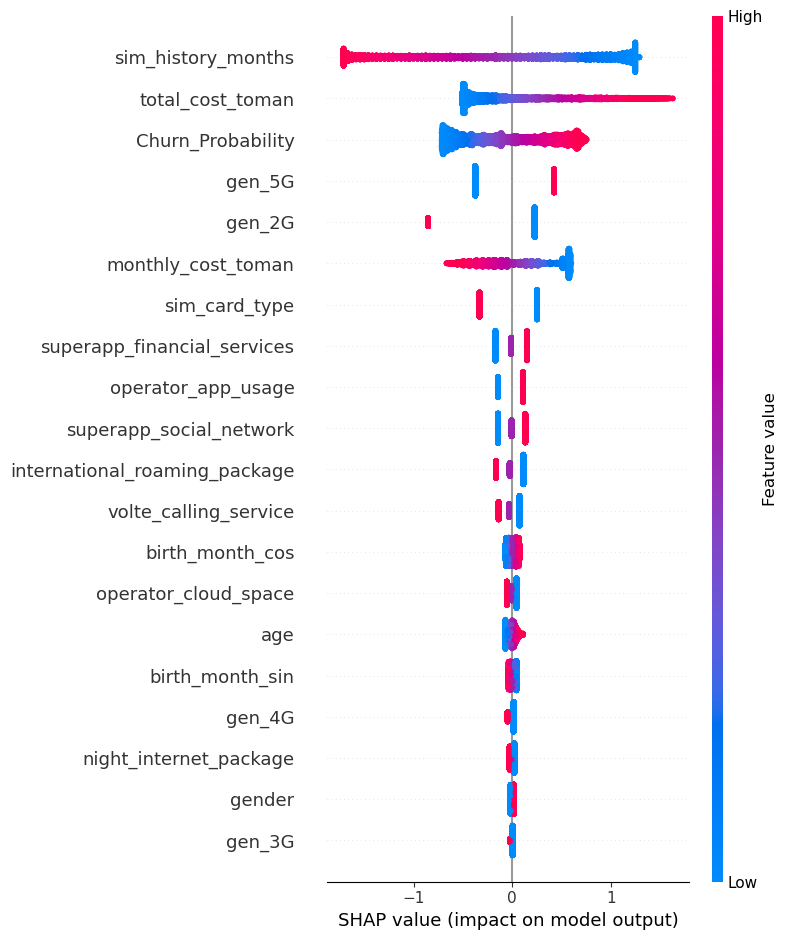

In [43]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values.values, x, feature_names=x.columns, show=False)
plt.tight_layout()
plt.show()

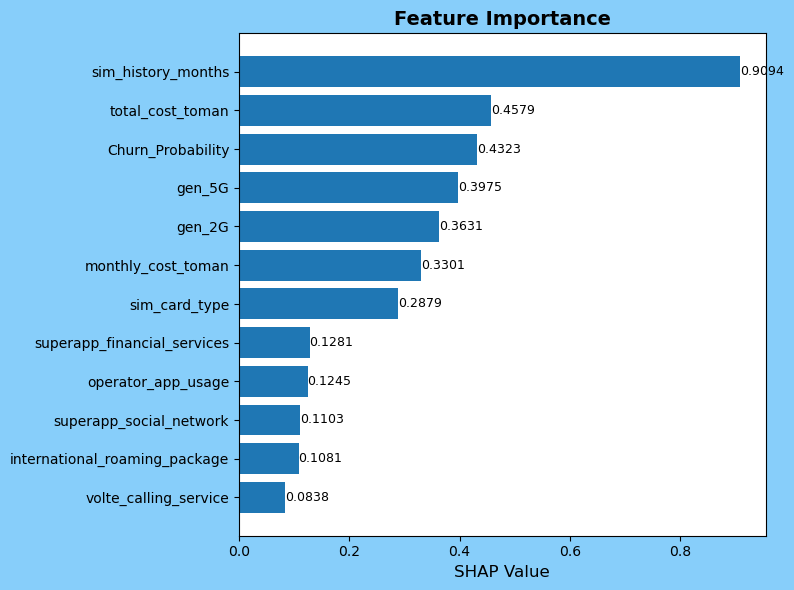

In [44]:
plt.figure(figsize=(8, 6), facecolor="lightskyblue")
tops = feature_importance.head(12)
bars = plt.barh(tops['Feature'], tops['Importance'],)
plt.xlabel('SHAP Value', fontsize=12)
plt.title('Feature Importance', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             ha='left', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [45]:
def extract_top_reasons(index, top_n=3):
    values = shap_values.values[index]
    tmp = pd.DataFrame({"feature": x.columns, "shap_value": values})

    # positive effect on churn
    tmp = tmp[tmp["shap_value"] > 0]

    tmp = tmp.sort_values(by = "shap_value",ascending = False)


    top_features = tmp.head(top_n)
    reasons = []

    for _, row in top_features.iterrows():
        reasons.append(
            f"{row['feature']} "
            f"(+{round(row['shap_value'],3)})"
        )

    return " .. ".join(reasons)

In [46]:
df["Top_Churn_Reasons"] = [extract_top_reasons(i) for i in range(len(df))]

In [47]:
def level(prob):
    if prob >= 0.75: return "High Risk"
    elif prob >= 0.4: return "Medium Risk"
    else: return "Low Risk"


df["Risk_Level"] = df["Churn_Probability"].apply(level)

In [48]:
df.to_csv(
    "Final_SHAP_Analysis.csv",
    index=False,
    encoding="utf-8-sig"
)